In [1]:
## For plotting

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## For model training

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import RandomizedSearchCV

## For logging
from loguru import logger


In [2]:
## Saving this data as .csv file to continue with Section 3: Training a machine learning algorithm
filepath = "../../data/processed/cleaned_data_final.csv"
df = pd.read_csv(filepath, encoding="utf-8")
logger.info(f"Imported data successfully from {filepath}")

2026-04-20 20:44:05.289 | INFO     | __main__:<module>:4 - Imported data successfully from ../../data/processed/cleaned_data_final.csv


In [3]:
df.head()

,Brand,Model,Year,Condition,Mileage,Gearbox,Fiscal Power,Fuel,Equipment,NoD,Origin,FO,Location,Sector,Price,num_features,condition_numeric,Mileage_mean
0,Volkswagen,Polo,1997,Good,200 000 - 249 999,Manual,8.0,Diesel,"['Leather Seats', 'CD/MP3/Bluetooth']",5,Unknown,0,Tétouan,City Center,27000.0,2,3,224999.5
1,Dacia,Sandero,2012,Very Good,180 000 - 189 999,Manual,6.0,Diesel,"['Rear Camera', 'Electric Windows']",5,WW in Morocco,0,Temara,City Center,69000.0,2,4,184999.5
2,Volkswagen,Polo,2004,Fair,300 000 - 349 999,Manual,8.0,Diesel,"['Alloy Wheels', 'Electric Windows']",5,WW in Morocco,0,Safi,Chenguite,45000.0,2,2,324999.5
3,mini,cooper,2013,Excellent,85 000 - 89 999,Automatic,8.0,Diesel,"['Airbags', 'CD/MP3/Bluetooth', 'Rear Camera',...",5,WW in Morocco,0,Fès,Agdal,128000.0,14,5,87499.5
4,Audi,A3,2015,New,200 000 - 249 999,Automatic,8.0,Diesel,"['Electric Windows', 'CD/MP3/Bluetooth']",5,Customs-cleared car,0,Marrakech,M'Hamid,220000.0,2,6,224999.5


In [4]:
df.drop(columns=["Equipment"], inplace=True)
df.head()

,Brand,Model,Year,Condition,Mileage,Gearbox,Fiscal Power,Fuel,NoD,Origin,FO,Location,Sector,Price,num_features,condition_numeric,Mileage_mean
0,Volkswagen,Polo,1997,Good,200 000 - 249 999,Manual,8.0,Diesel,5,Unknown,0,Tétouan,City Center,27000.0,2,3,224999.5
1,Dacia,Sandero,2012,Very Good,180 000 - 189 999,Manual,6.0,Diesel,5,WW in Morocco,0,Temara,City Center,69000.0,2,4,184999.5
2,Volkswagen,Polo,2004,Fair,300 000 - 349 999,Manual,8.0,Diesel,5,WW in Morocco,0,Safi,Chenguite,45000.0,2,2,324999.5
3,mini,cooper,2013,Excellent,85 000 - 89 999,Automatic,8.0,Diesel,5,WW in Morocco,0,Fès,Agdal,128000.0,14,5,87499.5
4,Audi,A3,2015,New,200 000 - 249 999,Automatic,8.0,Diesel,5,Customs-cleared car,0,Marrakech,M'Hamid,220000.0,2,6,224999.5


In [5]:
# Log-transform skewed columns
df['Price_log']   = np.log1p(df['Price'])
df['Mileage_log'] = np.log1p(df['Mileage_mean'])

# Car age is more intuitive than raw year
df['Age'] = 2025 - df['Year']
# Age × Mileage interaction — an old high-mileage car is much worse
df['Age_x_Mileage'] = df['Age'] * df['Mileage_log']

In [6]:
## Handeling outliers
# Train only on cars under 98th percentile price
q98 = df['Price'].quantile(0.98)
df_train_clean = df[df['Price'] <= q98]

df_train_clean.sort_values(by='Price', ascending=0).head(10)

,Brand,Model,Year,Condition,Mileage,Gearbox,Fiscal Power,Fuel,NoD,Origin,...,Location,Sector,Price,num_features,condition_numeric,Mileage_mean,Price_log,Mileage_log,Age,Age_x_Mileage
15141,Volkswagen,GOLF 8,2021,Excellent,40 000 - 44 999,Automatic,8.0,Diesel,5,Imported New,...,Casablanca,Sidi Bernoussi,415000.0,15,5,42499.5,12.936036,10.657271,4,42.629084
68445,Audi,Q3,2021,Excellent,95 000 - 99 999,Automatic,8.0,Diesel,5,WW in Morocco,...,Tanger,Tanger City Center,415000.0,10,5,97499.5,12.936036,11.487613,4,45.950451
8944,Porsche,Macan,2015,Excellent,170 000 - 179 999,Automatic,12.0,Diesel,5,Imported New,...,Agadir,Hay Salam,415000.0,15,5,174999.5,12.936036,12.072544,10,120.725441
62636,Volkswagen,Touareg,2020,Excellent,45 000 - 49 999,Automatic,12.0,Diesel,5,WW in Morocco,...,Casablanca,Belvédère,415000.0,13,5,47499.5,12.936036,10.768496,5,53.842478
63332,Audi,q3_sportback,2021,Excellent,80 000 - 84 999,Automatic,8.0,Diesel,5,WW in Morocco,...,Casablanca,Aïn Chock,415000.0,14,5,82499.5,12.936036,11.320560,4,45.282239
63329,Audi,q3_sportback,2021,Excellent,80 000 - 84 999,Automatic,8.0,Diesel,5,WW in Morocco,...,Casablanca,Aïn Chock,415000.0,14,5,82499.5,12.936036,11.320560,4,45.282239
23235,Volkswagen,Tiguan,2021,Excellent,100 000 - 109 999,Automatic,8.0,Diesel,5,Customs-cleared car,...,Casablanca,Californie,415000.0,15,5,104999.5,12.936036,11.561720,4,46.246882
51243,Volvo,XC90,2021,Excellent,140 000 - 149 999,Automatic,8.0,Diesel,5,WW in Morocco,...,Tanger,City Center,415000.0,15,5,144999.5,12.936036,11.884492,4,47.537970
9274,Audi,q3_sportback,2021,Excellent,80 000 - 84 999,Automatic,8.0,Diesel,5,WW in Morocco,...,Casablanca,Aïn Chock,415000.0,14,5,82499.5,12.936036,11.320560,4,45.282239
65655,Audi,Q3,2021,Excellent,95 000 - 99 999,Automatic,8.0,Diesel,5,WW in Morocco,...,Tanger,Tanger City Center,415000.0,10,5,97499.5,12.936036,11.487613,4,45.950451


## Using XGBoost
### Why XGBoost ?

- **Handles non-linear relationships** — price doesn't scale linearly with mileage, age, or fiscal power; XGBoost captures these curves naturally
- **Captures feature interactions** — learns that Brand × Year × Mileage combinations matter, without you manually engineering them
- **Works natively with mixed data** — numeric, ordinal, and encoded categorical features in the same model without issues
- **Built-in regularization** — `reg_alpha` and `reg_lambda` prevent overfitting on a noisy real-world scraping dataset
- **Robust to outliers in features** — tree splits are based on rank order, not raw values, so extreme mileage or fiscal power entries don't distort the model
- **Early stopping** — automatically finds the optimal number of trees without manual tuning, reducing overfitting risk
- **State of the art on tabular data** — consistently outperforms linear models and random forests on structured datasets in practice
- **Empirically validated on our data** — comparison against Linear Regression, Ridge, and Random Forest confirmed XGBoost achieved the best R² and MAPE on our test set

In [7]:
# 1. Define your feature matrix and target
drop_cols = ['Price', 'Price_log', 'Condition',
             'Mileage', 'Location', 'Sector', 'NoD']

X = df_train_clean.drop(columns=drop_cols)
y = df_train_clean['Price_log']

## Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


numeric_cols    = ['Year', 'Fiscal Power', 'Mileage_log', 'num_features', 'condition_numeric']

## One hot encoder columns
ohe_cols        = ['Gearbox', 'Fuel', 'Origin']

## Target encoder columns
## ???
target_enc_cols = ['Brand', 'Model']



preprocessor = ColumnTransformer(transformers=[
    ('num',    'passthrough',numeric_cols),
    ('ohe',    OneHotEncoder(drop='first', handle_unknown='ignore'),ohe_cols),
    ('target', TargetEncoder(target_type='continuous'),target_enc_cols),
])

# Fit preprocessor on train, transform both
X_train_processed = preprocessor.fit_transform(X_train, y_train)
X_test_processed  = preprocessor.transform(X_test)

optimized_params = {
    'subsample': 0.9,
    'reg_lambda': 5,
    'reg_alpha': 0,
    'subsample': 0.9,
    'n_estimators': 500,
    'max_depth': 8,
    'learning_rate': 0.05,
    'colsample_bytree': 0.7,
}

# Update the dict first (in-place), then unpack it
optimized_params.update({
    'device': 'cuda',
    'random_state': 42,
    'early_stopping_rounds': 50,
})

model = XGBRegressor(**optimized_params)

logger.info("Setting model to CPU")
model.set_params(device='cpu')

model.fit(
    X_train_processed, y_train,
    eval_set=[(X_test_processed, y_test)],
    verbose=50
)

y_pred_log = model.predict(X_test_processed)
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

2026-04-20 20:44:05.814 | INFO     | __main__:<module>:55 - Setting model to CPU


[0]	validation_0-rmse:0.66059
[50]	validation_0-rmse:0.24884
[100]	validation_0-rmse:0.23432
[150]	validation_0-rmse:0.23124
[200]	validation_0-rmse:0.22934
[250]	validation_0-rmse:0.22867
[300]	validation_0-rmse:0.22829
[334]	validation_0-rmse:0.22835


In [8]:
# --- Metrics ---
mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f"MAE:  {mae:,.0f} MAD")
print(f"RMSE: {rmse:,.0f} MAD")
print(f"R²:   {r2:.4f}")
print(f"MAPE: {mape:.2f}%")
filename = 'car_price_model.json'
model.save_model(filename)
logger.info(f"Saved model to disk filename {filename}")

MAE:  14,326 MAD
RMSE: 24,665 MAD
R²:   0.9066
MAPE: 15.41%


2026-04-20 20:44:08.846 | INFO     | __main__:<module>:13 - Saved model to disk filename car_price_model.json


In [9]:
###### RUN CELL ON COLAB T4 ################

# param_grid = {
#      'learning_rate':    [0.01, 0.05, 0.1],
#      'n_estimators':     [500, 1000, 1500],
#      'max_depth':        [4, 6, 8],
#      'subsample':        [0.7, 0.8, 0.9],
#      'colsample_bytree': [0.7, 0.8, 0.9],
#      'reg_lambda':       [1, 5, 10],       # L2 regularization
#      'reg_alpha':        [0, 0.1, 1],      # L1 regularization
# }
#
#
# search = RandomizedSearchCV(
#      XGBRegressor(random_state=42, device='cuda'),
#      param_grid,
#      n_iter=50,
#      cv=5,
#      scoring='r2',
#      n_jobs=1,
#      random_state=42,
#      verbose=True
#  )
# search.fit(X_train_proc, y_train)
# print(search.best_params_)
# print(search.best_score_)

In [10]:
results = {}
models = {
    'Linear Regression': LinearRegression(),
    'Ridge':             Ridge(alpha=0.1),
    'Lasso':             Lasso(alpha=0.1),
    'XGBoost':           XGBRegressor(**optimized_params),
}


for name, m in models.items():
    if name == 'XGBoost':
        m.set_params(device='cpu')
        m.fit(X_train_processed, y_train, eval_set=[(X_test_processed, y_test)], verbose=None)
    else:
        m.fit(X_train_processed, y_train)

    preds = np.expm1(m.predict(X_test_processed))
    true  = np.expm1(y_test)

    results[name] = {
        'R²':   r2_score(true, preds),
        'MAE':  mean_absolute_error(true, preds),   # ← fixed
        'RMSE': np.sqrt(mean_squared_error(true, preds)),  # ← fixed
        'MAPE': np.mean(np.abs((true - preds) / true)) * 100
    }

    print(f"{name:20s} → R²: {results[name]['R²']:.4f}  MAPE: {results[name]['MAPE']:.2f}%   RMSE: {results[name]['RMSE']:,.0f} MAD  MAE: {results[name]['MAE']:,.0f} MAD")

Linear Regression    → R²: 0.7975  MAPE: 22.04%   RMSE: 36,315 MAD  MAE: 22,610 MAD
Ridge                → R²: 0.7975  MAPE: 22.04%   RMSE: 36,315 MAD  MAE: 22,610 MAD
Lasso                → R²: 0.5221  MAPE: 32.96%   RMSE: 55,793 MAD  MAE: 36,177 MAD
XGBoost              → R²: 0.9066  MAPE: 15.41%   RMSE: 24,665 MAD  MAE: 14,326 MAD


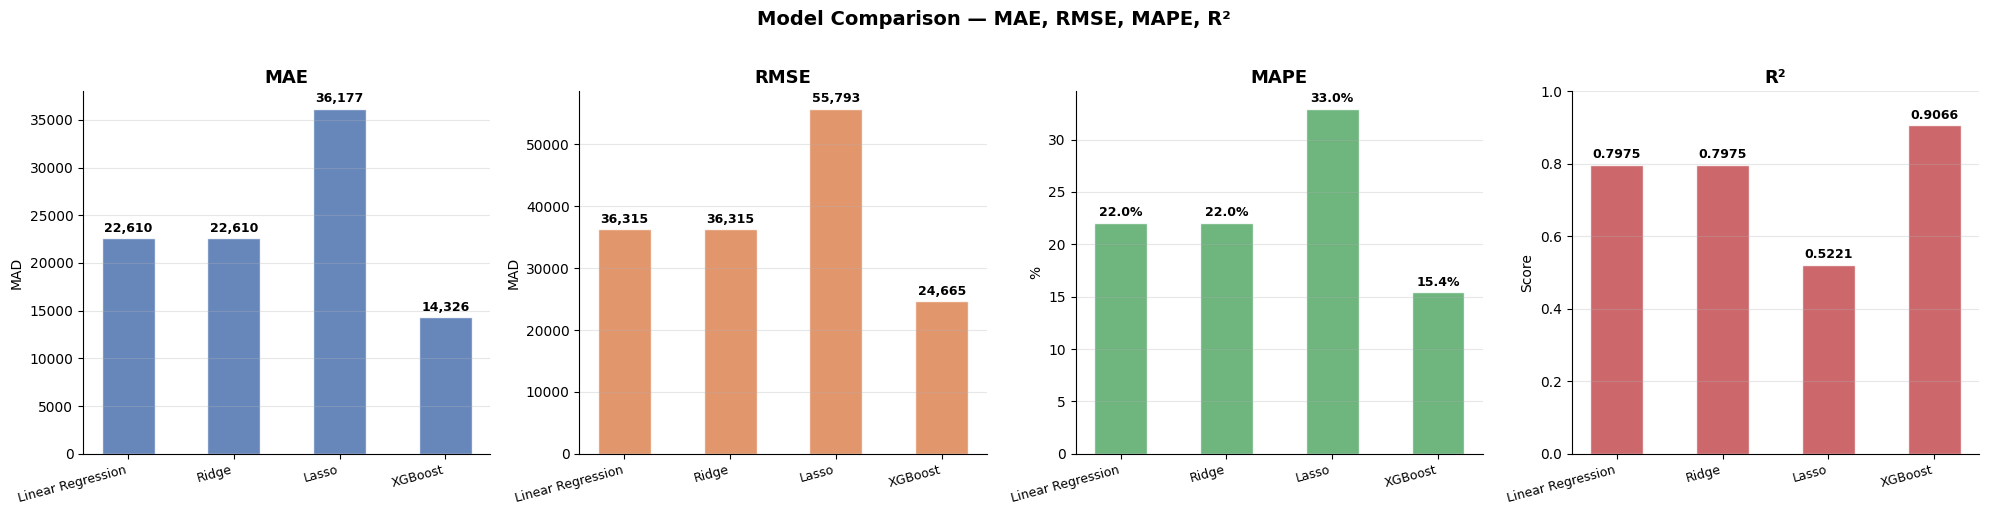

In [11]:
models_list = list(results.keys())
metrics = ['MAE', 'RMSE', 'MAPE', 'R²']
colors  = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
x = np.arange(1,5)

for i, (ax, metric) in enumerate(zip(axes, metrics)):
    values = [results[m][metric] for m in models_list]
    bars = ax.bar(x, values, width=0.5, color=colors[i], alpha=0.85, edgecolor='white')

    for bar, val in zip(bars, values):
        if metric == 'MAPE':
            label = f'{val:.1f}%'
        elif metric == 'R²':
            label = f'{val:.4f}'
        else:
            label = f'{val:,.0f}'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values)*0.01,
                label, ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models_list, rotation=15, ha='right', fontsize=9)

    if metric == 'MAPE':
        ax.set_ylabel('%')
    elif metric == 'R²':
        ax.set_ylabel('Score')
        ax.set_ylim(0, 1)        # R² is always 0–1
    else:
        ax.set_ylabel('MAD')

    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Model Comparison — MAE, RMSE, MAPE, R²', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../../figures/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()